Loading real-world Telco Churn dataset...
Training LightGBM Model with Class Weights...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- GENERATING KHAMSAT PORTFOLIO VISUALS ---



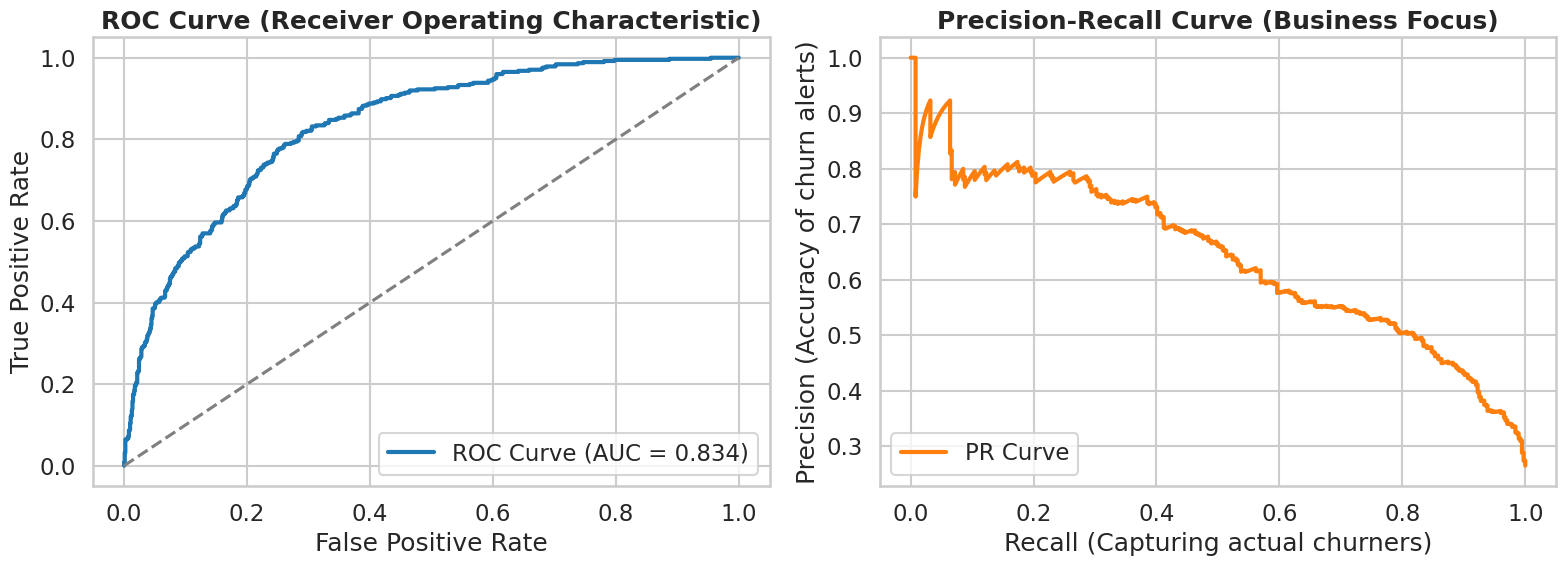

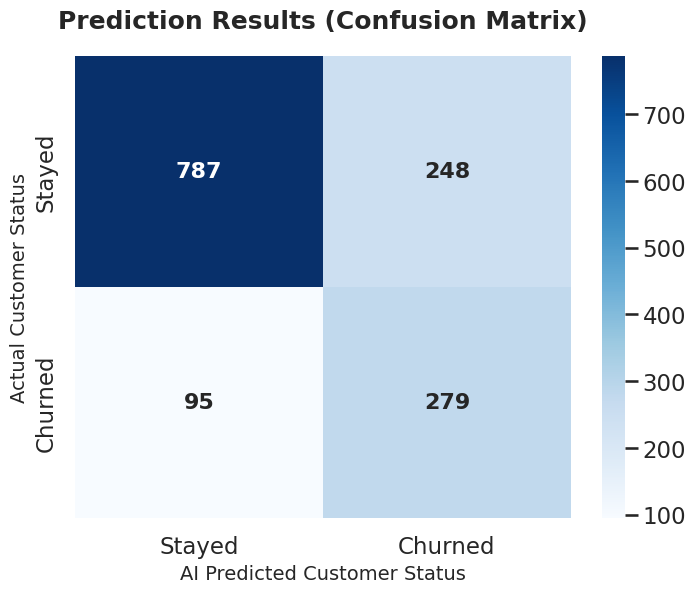


Calculating SHAP values for Explainable AI (This might take a few seconds)...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


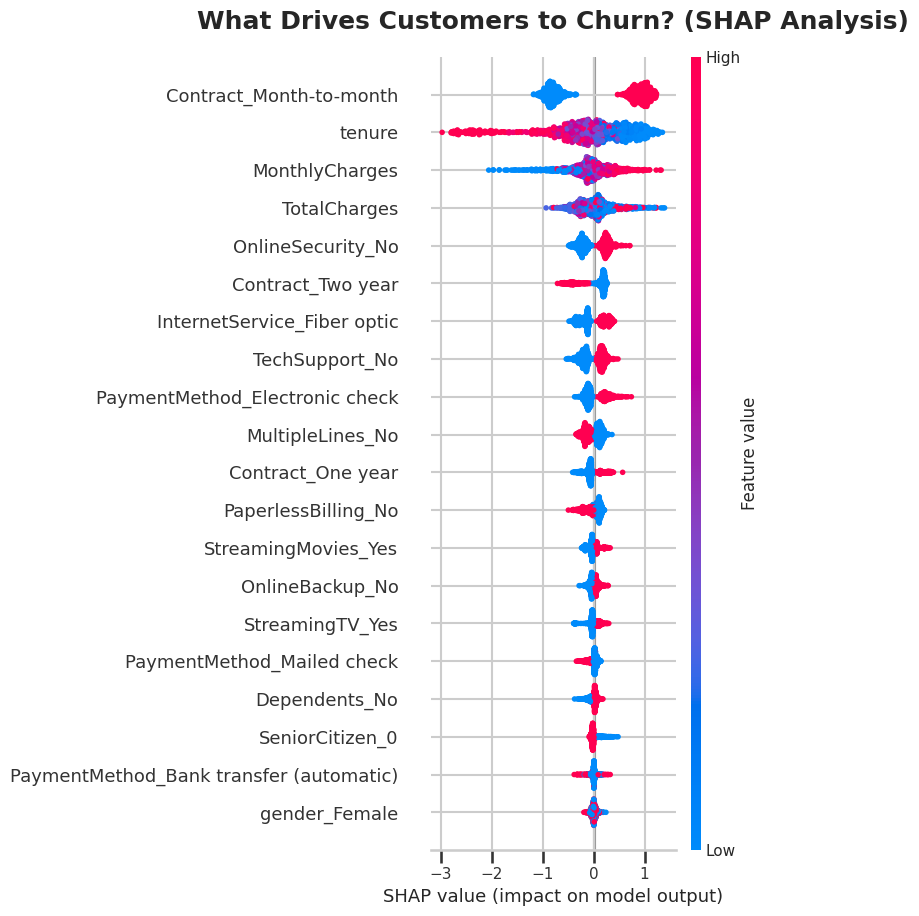


Code execution complete. Take screenshots of these visuals for your Khamsat gallery!


In [ ]:
# ==========================================
# 1. INSTALL AND IMPORT REQUIRED LIBRARIES
# ==========================================
!pip install -q lightgbm shap scikit-learn matplotlib seaborn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report
from lightgbm import LGBMClassifier

# Set professional plotting style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# 2. LOAD & PREPARE DATASET (Telco Churn)
# ==========================================
print("Loading real-world Telco Churn dataset...")
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Basic cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.drop('customerID', axis=1, inplace=True) # Drop ID column

# Split data
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 3. BUILD SENIOR-LEVEL ML PIPELINE
# ==========================================
# Identify column types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

# Preprocessing steps
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ==========================================
# 4. TRAIN LIGHTGBM MODEL
# ==========================================
print("Training LightGBM Model with Class Weights...")
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        class_weight='balanced', # Handles imbalanced churn data
        random_state=42,
        verbose=-1
    ))
])

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ==========================================
# 5. GENERATE PORTFOLIO-READY VISUALS
# ==========================================
print("\n--- GENERATING KHAMSAT PORTFOLIO VISUALS ---\n")

# Visual 1: Advanced Evaluation Metrics (ROC & PR Curves)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
ax[0].plot(fpr, tpr, color='#1f77b4', lw=3, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[0].set_title('ROC Curve (Receiver Operating Characteristic)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')

# Precision-Recall Curve (Crucial for imbalanced Churn data)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ax[1].plot(recall, precision, color='#ff7f0e', lw=3, label='PR Curve')
ax[1].set_title('Precision-Recall Curve (Business Focus)', fontweight='bold')
ax[1].set_xlabel('Recall (Capturing actual churners)')
ax[1].set_ylabel('Precision (Accuracy of churn alerts)')
ax[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Visual 2: Professional Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            annot_kws={"size": 16, "weight": "bold"})
plt.title('Prediction Results (Confusion Matrix)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Actual Customer Status', fontsize=14)
plt.xlabel('AI Predicted Customer Status', fontsize=14)
plt.show()

# Visual 3: SHAP Explainable AI (XAI) - The "Magic" Visual
print("\nCalculating SHAP values for Explainable AI (This might take a few seconds)...")
# Extract transformed data and feature names to feed into SHAP
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

# Get feature names from the ColumnTransformer
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_features)

# Calculate SHAP
explainer = shap.TreeExplainer(model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

# Plot SHAP Summary
plt.figure(figsize=(12, 8))
plt.title("What Drives Customers to Churn? (SHAP Analysis)", fontsize=18, fontweight='bold', pad=20)
# LightGBM binary classification returns a list of shap values for some versions, take the positive class [1]
shap_vals_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(shap_vals_to_plot, X_test_transformed, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

print("\nCode execution complete. Take screenshots of these visuals for your Khamsat gallery!")